<a href="https://colab.research.google.com/github/lepcodes/deep-learning-class/blob/main/A05_Redes_Densas_TF/Housing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Housing Dataset

### Import Dependencies


In [29]:
import pandas as pd
import tensorflow as tf
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import OneHotEncoder
import matplotlib.pyplot as plt
print("TF version:", tf.__version__)
print("Built with CUDA:", tf.test.is_built_with_cuda())
print("Physical GPUs:", tf.config.list_physical_devices("GPU"))



TF version: 2.19.0
Built with CUDA: True
Physical GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Data Import

In [ ]:
!curl https://raw.githubusercontent.com/lepcodes/deep-learning-class/refs/heads/main/Datasets/Housing.csv -o Housing.csv
data = pd.read_csv('Housing.csv')

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 29981  100 29981    0     0   312k      0 --:--:-- --:--:-- --:--:--  314k


## 2. Explore the Dataset

In [31]:
data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


View data distribution and possible outliers

In [32]:
data.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


Check datatypes of features

In [33]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


Check values of categorical features

In [34]:
categorical_features = data.select_dtypes(include=['object']).columns
unique_vals = {col: data[col].unique() for col in categorical_features}
unique_vals

{'mainroad': array(['yes', 'no'], dtype=object),
 'guestroom': array(['no', 'yes'], dtype=object),
 'basement': array(['no', 'yes'], dtype=object),
 'hotwaterheating': array(['no', 'yes'], dtype=object),
 'airconditioning': array(['yes', 'no'], dtype=object),
 'prefarea': array(['yes', 'no'], dtype=object),
 'furnishingstatus': array(['furnished', 'semi-furnished', 'unfurnished'], dtype=object)}

## 3. Clean Data and Encode Categorical Variables

Check for null values

In [35]:
data.isna().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


Check for duplicated values in the dataset

In [36]:
data.duplicated().sum()

np.int64(0)

Encode categorical features

In [37]:
binary_features = data[categorical_features].drop('furnishingstatus', axis=1)
binary_features = binary_features.replace({'yes': 1, 'no': 0})

one_hot_features = OneHotEncoder(sparse_output=False).fit_transform(data[['furnishingstatus']])
one_hot_features = pd.DataFrame(one_hot_features, columns=['furnished', 'semi-furnished', 'unfurnished'])

/tmp/ipython-input-3737112857.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  binary_features = binary_features.replace({'yes': 1, 'no': 0})


## 4. Select Input and Output Features

### Output Features

In [38]:
y_df = data['price']

### Input Features

In [39]:
numeric_features = data.select_dtypes(include=['int64', 'float64']).drop('price', axis=1)
X_df = pd.concat([numeric_features, binary_features, one_hot_features], axis=1)

## 5. Split the Data and Normalize

Split the Data

In [40]:
X_train, X_test, y_train, y_test = train_test_split(X_df, y_df, test_size=0.2, random_state=42)

Standarize input training data (only numeric features)

In [41]:
scaler = MinMaxScaler()
numeric_cols = numeric_features.columns
X_train[numeric_cols] = pd.DataFrame(scaler.fit_transform(X_train[numeric_cols]), columns=numeric_cols, index=X_train.index)

Standarize input testing data

In [42]:
X_test[numeric_cols] = pd.DataFrame(scaler.transform(X_test[numeric_cols]), columns=numeric_cols, index=X_test.index)

Standarize output

In [43]:
scaler_y = MinMaxScaler()
y_train = pd.DataFrame(scaler_y.fit_transform(y_train.values.reshape(-1, 1)), columns=['price'], index=y_train.index)
y_test = pd.DataFrame(scaler_y.transform(y_test.values.reshape(-1, 1)), columns=['price'], index=y_test.index)

Check the effects of the standarization

In [44]:
X_train.describe()

,area,bedrooms,bathrooms,stories,parking,mainroad,guestroom,basement,hotwaterheating,airconditioning,prefarea,furnished,semi-furnished,unfurnished
count,436.000000,436.000000,436.000000,436.000000,436.000000,436.000000,436.000000,436.000000,436.000000,436.000000,436.000000,436.000000,436.000000,436.000000
mean,0.240835,0.391743,0.088685,0.260703,0.228593,0.857798,0.178899,0.357798,0.050459,0.307339,0.233945,0.254587,0.431193,0.314220
std,0.151499,0.149561,0.159130,0.286031,0.284980,0.349658,0.383708,0.479903,0.219141,0.461921,0.423824,0.436129,0.495812,0.464738
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.134021,0.200000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.195876,0.400000,0.000000,0.333333,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.323711,0.400000,0.333333,0.333333,0.333333,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


### Dataset Ready

In [45]:
print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

print("Training label size:", y_train.shape)
print("Test label size:", y_test.shape)

Training set size: (436, 14)
Test set size: (109, 14)
Training label size: (436, 1)
Test label size: (109, 1)


## 6. Design Deep Neural Network for Regression

Callback

In [46]:
callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

Hyperparameters

In [47]:
LEARNING_RATE = 1e-5
BATCH_SIZE = 32
EPOCHS = 300

In [48]:
model_1 = Sequential([
    Input(shape=(14,)),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='linear')
])
model_1.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='mse',
    metrics=[
      tf.keras.metrics.MeanAbsoluteError(name='mae'),
      tf.keras.metrics.R2Score(name='r2_score')
    ]
)
# model_1.summary()

## 7. Train Network and Draw Evolution

Training

In [49]:
history = model_1.fit(
    X_train,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test, y_test),
    callbacks=[callback],
    verbose=0
)

Evolution

In [50]:
def plot_overfitting(history):
    # Plot loss
    plt.figure(figsize=(18, 5))

    plt.subplot(1, 3, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training vs Validation Loss')
    plt.legend()

    plt.subplot(1, 3, 2)
    plt.plot(history.history['mae'], label='Training MAE')
    plt.plot(history.history['val_mae'], label='Validation MAE')
    plt.xlabel('Epochs')
    plt.ylabel('MAE')
    plt.title('Training vs Validation MAE')
    plt.legend()

    plt.subplot(1, 3, 3)
    plt.plot(history.history['r2_score'], label='Training R2 Score')
    plt.plot(history.history['val_r2_score'], label='Validation R2 Score')
    plt.xlabel('Epochs')
    plt.ylabel('R2 Score')
    plt.title('Training vs Validation R2 Score')
    plt.legend()
    plt.show()

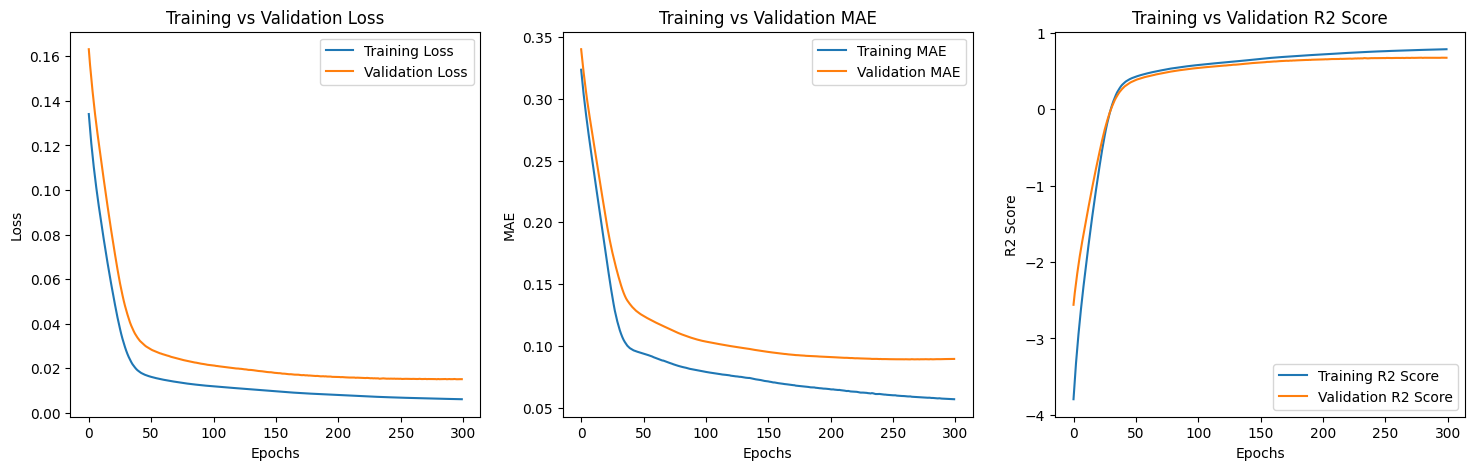

In [51]:
plot_overfitting(history)

## 8. Find Better Hyperparameters

Hyperparameters

In [52]:
LEARNING_RATE = 0.001
BATCH_SIZE = 32
EPOCHS = 300

Build new model

In [53]:
model_2 = Sequential(
  [
    Input(shape=(14,)),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.8),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dense(1, activation='linear')
  ]
)
model_2.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='mse',
    metrics=[
      tf.keras.metrics.MeanAbsoluteError(name='mae'),
      tf.keras.metrics.R2Score(name='r2_score')
    ]
)
# model_2.summary()

Train new model

In [54]:
history = model_2.fit(
    X_train,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test, y_test),
    callbacks=[callback],
    verbose=0
)

Evolution

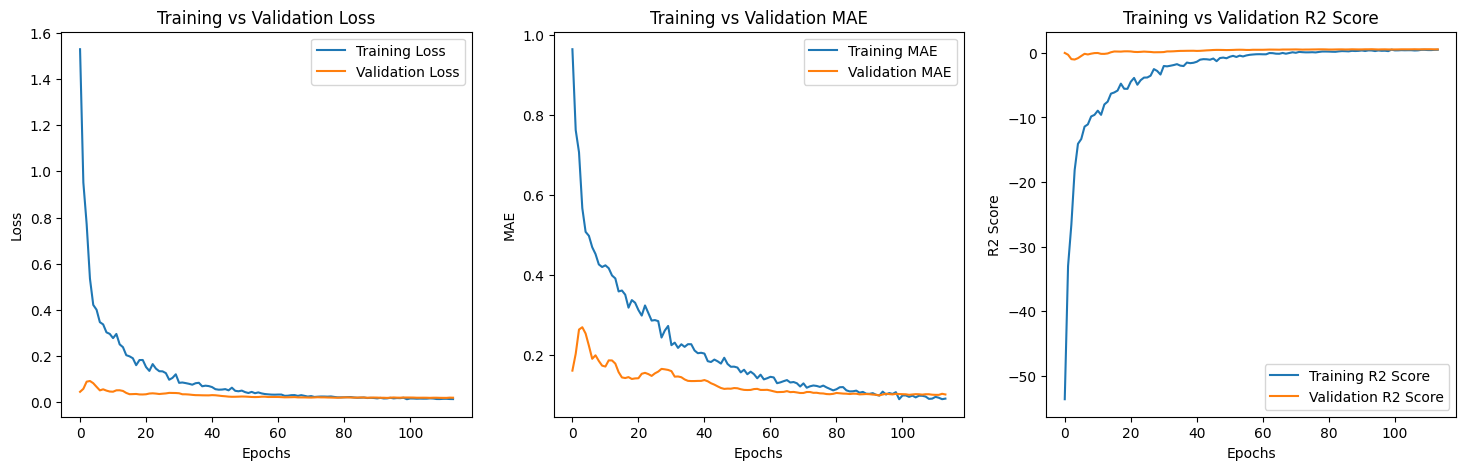

In [55]:
plot_overfitting(history)

## 9. Performance Metrics

In [56]:
print("Model 1 - Metrics")
result = model_1.evaluate(X_test, y_test, verbose=0)
print(f"Loss: {result[0]}, MAE: {result[1]}, R2 Score: {result[2]}")
print("\n")
print("Model 2 - Metrics")
result = model_2.evaluate(X_test, y_test, verbose=0)
print(f"Loss: {result[0]}, MAE: {result[1]}, R2 Score: {result[2]}")

Model 1 - Metrics
Loss: 0.015027787536382675, MAE: 0.08914462476968765, R2 Score: 0.6722148060798645


Model 2 - Metrics
Loss: 0.019332529976963997, MAE: 0.09946732968091965, R2 Score: 0.5783200263977051
